In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups

pd.set_option("display.max_colwidth", 300)

In [2]:
categories = [
    "alt.atheism",
    "comp.graphics",
    "rec.sport.baseball",
    "sci.med",
    "talk.politics.misc"
]

dataset = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

df = pd.DataFrame({
    "text": dataset.data,
    "target": dataset.target
})

df["category"] = df["target"].map(lambda x: dataset.target_names[x])

df.head()

,text,target,category
0,": >over where it places its temp files: it just places them in its\n: >""current directory"".\n\n: I have to beg to differ on this point, as the batch file I use\n: to launch cview cd's to the dir where cview resides and then\n: invokes it. every time I crash cview, the 0-byte temp file\n: is fou...",1,comp.graphics
1,"\nTom Prince is a 28 year old no-hit catcher. Think of him as a young Dann\nBilardello. I can't begin to fathom why the Pirates have been so afraid of\nlosing this guy, who's been in AAA most of the last 5 seasons. The Pirates\nreleased Kirk Gibson last year because Prince was out of options,...",2,rec.sport.baseball
2,I'm sure all of you have heard of the extraordiary start by rookie\nJ.T. Snow of the California Angeles. Other than the fact that his\nfather was a star receiver with the L.A. Rams and is now a radio\npersonality in Los Angeles and J.T. came from the Yankees organization\nI don't know much abo...,2,rec.sport.baseball
3,"I have a friend who has just been diagnosed with Lupus, and I know nothing\nabout this disease. The only thing I do know is that this is some sort of\nskin disease, and my friend shows no skin rashes - in fact, they used a \nblood test to determine what had been wrong with an on going sacro-\nil...",3,sci.med
4,"\n\nWhile I don't have an answer for you, I reckon Blaise Pascal is generally\ncredited with inventing the syringe per se. I don't know much about the\nneedles; however, I do know of a southwest Virginia country doctor who\nsome thrity or more years ago invented, patented, used, and sold a syri...",3,sci.med


In [3]:
df.shape

(4531, 3)

In [4]:
df["category"].value_counts()

category
rec.sport.baseball    994
sci.med               990
comp.graphics         973
alt.atheism           799
talk.politics.misc    775
Name: count, dtype: int64

In [5]:
df.to_csv("../data/raw/news_dataset.csv", index=False)

In [6]:
df["text_length"] = df["text"].str.len()

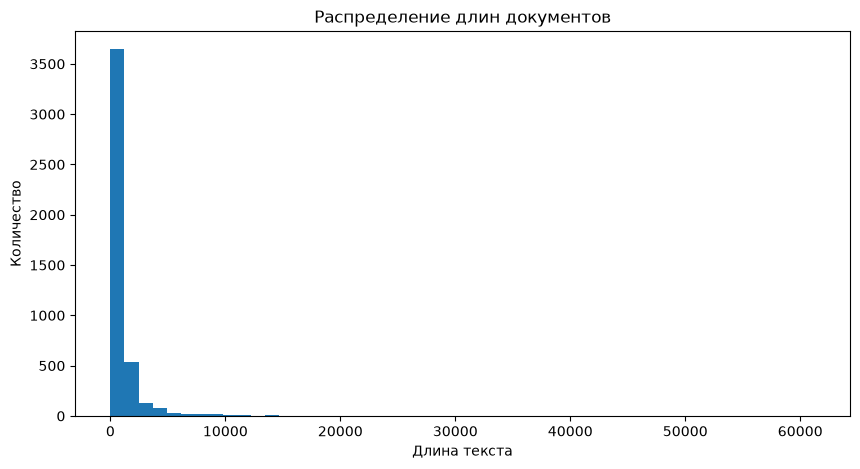

In [7]:
plt.figure(figsize=(10,5))

plt.hist(df["text_length"], bins=50)

plt.xlabel("Длина текста")
plt.ylabel("Количество")
plt.title("Распределение длин документов")

plt.show()

In [8]:
df.groupby("category")["text_length"].mean().sort_values()

category
rec.sport.baseball     724.451710
alt.atheism           1180.553191
comp.graphics         1294.299075
sci.med               1309.617172
talk.politics.misc    1723.335484
Name: text_length, dtype: float64

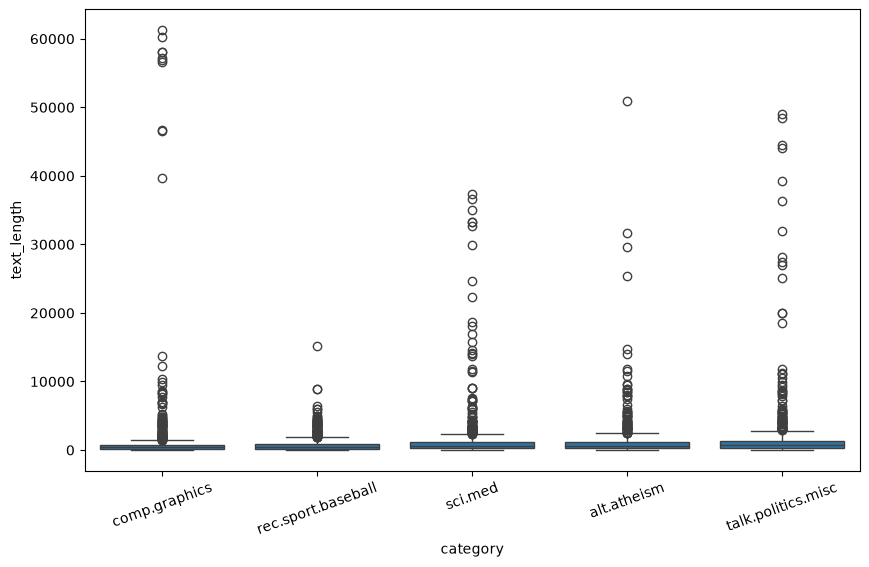

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="category",
    y="text_length"
)

plt.xticks(rotation=20)

plt.show()

In [10]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [11]:
sample = df.iloc[0]["text"]

print(sample[:500])

: >over where it places its temp files: it just places them in its
: >"current directory".

: I have to beg to differ on this point, as the batch file I use
: to launch cview cd's to the dir where cview resides and then
: invokes it.  every time I crash cview, the 0-byte temp file
: is found in the root dir of the drive cview is on.

I posted this as well before the cview "expert".  Apparently, he thought he
knew better.


In [12]:
from src.news_classifier.preprocess import clean_text

In [13]:
sample = df.iloc[0]["text"]

print(clean_text(sample))

place temp file place current directory beg differ point batch file use launch cview cd dir cview resides invokes every time crash cview byte temp file found root dir drive cview posted well cview expert apparently thought knew better


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, f1_score, classification_report

In [16]:
df["clean_text"] = df["text"].apply(clean_text)

In [17]:
X = df["clean_text"]
y = df["category"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [20]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "model": name,
        "accuracy": accuracy,
        "f1_weighted": f1
    })

results_df = pd.DataFrame(results)
results_df.sort_values("f1_weighted", ascending=False)

,model,accuracy,f1_weighted
1,Logistic Regression,0.883131,0.882219
0,Naive Bayes,0.882029,0.880900
2,Linear SVM,0.879824,0.879251


In [21]:
best_model = models["Linear SVM"]

y_pred = best_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

       alt.atheism       0.84      0.84      0.84       160
     comp.graphics       0.92      0.93      0.93       195
rec.sport.baseball       0.88      0.91      0.89       199
           sci.med       0.90      0.91      0.90       198
talk.politics.misc       0.85      0.78      0.81       155

          accuracy                           0.88       907
         macro avg       0.88      0.87      0.87       907
      weighted avg       0.88      0.88      0.88       907



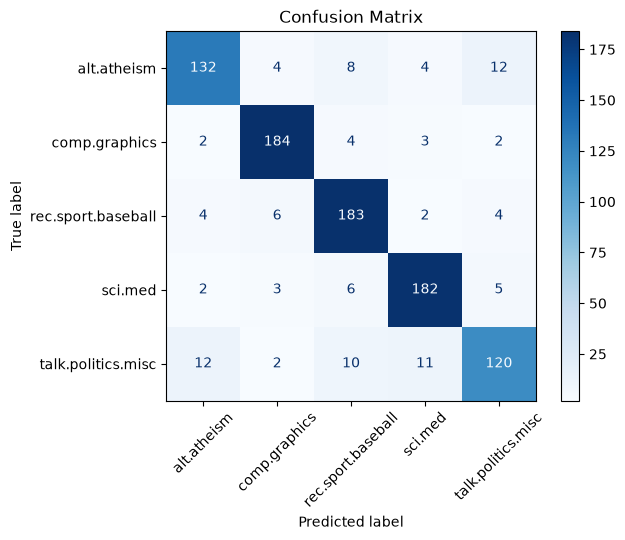

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = models["Logistic Regression"]

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [23]:
feature_names = vectorizer.get_feature_names_out()

coef = best_model.coef_

In [24]:
import numpy as np

classes = best_model.classes_

for i, category in enumerate(classes):
    top = np.argsort(coef[i])[-15:]

    print("=" * 60)
    print(category)

    for idx in reversed(top):
        print(feature_names[idx])

alt.atheism
god
religion
atheist
bible
islam
deletion
moral
islamic
atheism
morality
christian
jesus
objective
muslim
bobby
comp.graphics
graphic
file
image
program
computer
format
software
ftp
color
version
code
looking
xv
algorithm
thanks
rec.sport.baseball
game
team
baseball
player
pitcher
ball
fan
hit
year
league
season
play
stats
jewish
stadium
sci.med
doctor
medical
disease
food
patient
msg
effect
information
treatment
photography
pain
diet
cause
infection
blood
talk.politics.misc
government
clinton
tax
homosexual
gay
people
state
president
drug
law
batf
child
mr
men
insurance


<Figure size 1000x800 with 0 Axes>

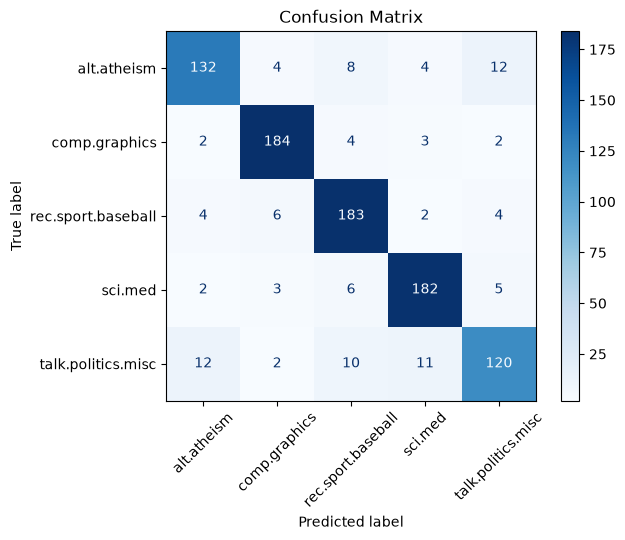

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [26]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

for i, category in enumerate(best_model.classes_):

    print("=" * 70)
    print(category)

    top_positive = np.argsort(best_model.coef_[i])[-15:]

    for idx in reversed(top_positive):
        print(feature_names[idx])

alt.atheism
god
religion
atheist
bible
islam
deletion
moral
islamic
atheism
morality
christian
jesus
objective
muslim
bobby
comp.graphics
graphic
file
image
program
computer
format
software
ftp
color
version
code
looking
xv
algorithm
thanks
rec.sport.baseball
game
team
baseball
player
pitcher
ball
fan
hit
year
league
season
play
stats
jewish
stadium
sci.med
doctor
medical
disease
food
patient
msg
effect
information
treatment
photography
pain
diet
cause
infection
blood
talk.politics.misc
government
clinton
tax
homosexual
gay
people
state
president
drug
law
batf
child
mr
men
insurance


In [27]:
examples = [
    "Microsoft released a new AI model for developers.",
    "The baseball team won the championship yesterday.",
    "Doctors discovered a new treatment for cancer.",
    "The president signed a new economic law.",
    "3D graphics rendering became much faster."
]

In [28]:
examples_clean = [clean_text(text) for text in examples]

examples_vectorized = vectorizer.transform(examples_clean)

predictions = best_model.predict(examples_vectorized)

for text, pred in zip(examples, predictions):
    print("=" * 60)
    print(text)
    print("Prediction:", pred)

Microsoft released a new AI model for developers.
Prediction: comp.graphics
The baseball team won the championship yesterday.
Prediction: rec.sport.baseball
Doctors discovered a new treatment for cancer.
Prediction: sci.med
The president signed a new economic law.
Prediction: talk.politics.misc
3D graphics rendering became much faster.
Prediction: comp.graphics


In [29]:
from joblib import dump

dump(best_model, "../models/logistic_regression.joblib")
dump(vectorizer, "../models/tfidf_vectorizer.joblib")

['../models/tfidf_vectorizer.joblib']

In [30]:
import os

os.listdir("../models")

['logistic_regression.joblib', 'tfidf_vectorizer.joblib']

In [31]:
import json

metadata = {
    "model": "Logistic Regression",
    "vectorizer": "TF-IDF",
    "accuracy": 0.883131,
    "f1_weighted": 0.882219,
    "dataset": "20 Newsgroups",
    "classes": list(best_model.classes_)
}

with open("../models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [32]:
from joblib import load

loaded_model = load("../models/logistic_regression.joblib")
loaded_vectorizer = load("../models/tfidf_vectorizer.joblib")

In [33]:
sample = clean_text(
    "Artificial intelligence is transforming software engineering."
)

sample_vector = loaded_vectorizer.transform([sample])

prediction = loaded_model.predict(sample_vector)

print(prediction)

['comp.graphics']
